In [183]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

importlib.reload(main_functions) 
from main_functions import *

In [185]:
tatneft = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\TATN.txt')
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_1candle_tatneft.pkl', 'rb') as file:
    tatneft_result = pickle.load(file)
display(tatneft_result.head(3))
display(tatneft.head(2))

,ticker,strategy name,period,N,lower_shadow_rate,up_shadow_rate,body_rate,count of trades,profit factor,total percent return,...,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model
0,TATN,hammer,30 min,40,1.5,0.05,0.4,814,1.253,329.03,...,40.9,time 2009-01-11 17:00:00 106310.000000 2009...,time 2009-01-11 17:00:00 106362.000000 2009...,time 2009-01-11 17:00:00 0.06310 2009-01-16...,time 2009-01-11 17:00:00 0.06362 2009-01-16...,22.5,24.5,23.5,16.5,87.0
1,TATN,hammer,30 min,40,1.5,0.05,0.5,814,1.253,329.03,...,40.9,time 2009-01-11 17:00:00 106310.000000 2009...,time 2009-01-11 17:00:00 106362.000000 2009...,time 2009-01-11 17:00:00 0.06310 2009-01-16...,time 2009-01-11 17:00:00 0.06362 2009-01-16...,22.5,24.5,23.5,16.5,87.0
2,TATN,hammer,30 min,40,1.5,0.10,0.5,806,1.290,438.93,...,49.5,time 2009-01-11 17:00:00 106310.000000 2009...,time 2009-01-11 17:00:00 106362.000000 2009...,time 2009-01-11 17:00:00 0.06310 2009-01-16...,time 2009-01-11 17:00:00 0.06362 2009-01-16...,24.5,21.5,23.5,14.5,84.0


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,TATN,1,20090111,103000,56.25,58.00,56.25,57.17,11386
1,TATN,1,20090111,103100,57.18,57.19,56.70,56.71,4136


In [186]:
tatneft_graph = good_dataframe(tatneft, timeframe='30 min')

In [187]:
def detection_of_hammer(data, lower_shadow_rate=1.5, body_rate=0.4, up_shadow_rate=0.05):

    """
    Обнаружение бычьего паттерна "Молот" (Hammer).
    
    Паттерн "Молот" - это односвечная модель разворота, которая формируется на нисходящем тренде
    и сигнализирует о потенциальном развороте вверх. Характеризуется маленьким телом в верхней
    части свечи и длинной нижней тенью.
    
    Параметры паттерна:
        - Тело свечи занимает небольшую часть от всего диапазона (по умолчанию ≤30%)
        - Нижняя тень значительно длиннее тела (по умолчанию ≥2 * тела)
        - Верхняя тень минимальна или отсутствует (по умолчанию ≤ 0.1 * тела)
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - open (float): Цена открытия
            - high (float): Максимальная цена
            - low (float): Минимальная цена
            - close (float): Цена закрытия
        lower_shadow_rate (float): Минимальное соотношение нижней тени к телу.
                                   По умолчанию 2 (нижняя тень > 2 * тела).
        body_rate (float): Максимальное соотношение тела ко всей свече.
                           По умолчанию 0.3 (тело < 30% свечи).
        up_shadow_rate (float): Максимальное соотношение верхней тени к телу.
                                По умолчанию 1 (верхняя тень < 0.1 * тела).
    
    Returns:
        pd.DataFrame: Исходный DataFrame с дополнительными столбцами:
            - pattern (int): 1 - обнаружен паттерн "Молот" на текущей свече,
                             0 - паттерн отсутствует
            - strategy (str): Название стратегии - 'hummer'
    
"""
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['lower_shadow_rate'] = lower_shadow_rate
    data['up_shadow_rate'] = up_shadow_rate
    data['body_rate'] = body_rate
    data['strategy'] = 'hammer'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])
    lower_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    

    # Базовое условие для формации молот
    mask = ((body / full_candle < body_rate) & 
                      (lower_shadow / body > lower_shadow_rate) &
                      (up_shadow / body < up_shadow_rate))

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [188]:
def preperation_to_modeling_1candle(data, period, func, N, profit):
    """Функция предназначена для подготовки датафрейма к дальнейшему моделированию

    Args:
        data (pd.DataFrame): 1-минутный таймфрейм
        period (object): Передаем период из стратегии
        func (function): Какой паттерн проверяем?
        N (int): Сколько следующих свеч удерживаем паттерн?
        profit (pd.Series): Численные результаты торгов

    Returns:
        Подготовленный датафрейм для использования ml
    """
    data_timeframe = good_dataframe(data, period)
    data_with_pattern = func(data_timeframe)
    
    # Обрезка
    data_with_pattern.loc[len(data_with_pattern) - 51 : len(data_with_pattern), ['pattern', 'signal']] = 0
    data_filter = filter_min_distance(data_with_pattern, 'signal', N)
    data_filter['signal'] = data_filter['signal'].shift(-1)
    
    
    data_filter.drop(['pattern', 'lower_shadow_rate', 'up_shadow_rate', 'body_rate', 'per', 'ticker', 'strategy'], axis=1, inplace=True)
    data_filter.dropna(inplace=True)
    
    # Соединяем доходности
    result = profit.loc[0, 'profit percent net']
    data_filter = data_filter.set_index('time')
    final_data = data_filter.join(result).fillna(0)
    final_data = final_data.reset_index()
    final_data['profit_percent_net'] = final_data['profit_percent_net'].shift(-1)
    final_data.dropna(inplace=True)
    return final_data

df = preperation_to_modeling_1candle(tatneft, '30 min', detection_of_hammer, 40, tatneft_result)

In [189]:
df

,time,open,high,low,close,volume,signal,profit_percent_net
0,2009-01-11 10:30:00,56.25,58.00,55.20,56.00,136272,0.0,0.0
1,2009-01-11 11:00:00,56.00,56.20,55.64,55.64,79221,0.0,0.0
2,2009-01-11 11:30:00,55.63,56.19,55.62,55.95,42323,0.0,0.0
3,2009-01-11 12:00:00,55.90,56.15,55.75,56.15,62833,0.0,0.0
4,2009-01-11 12:30:00,56.15,56.16,55.91,55.95,27339,0.0,0.0
...,...,...,...,...,...,...,...,...
93986,2026-03-31 20:30:00,664.30,665.00,664.00,664.90,10375,0.0,0.0
93987,2026-03-31 21:00:00,664.80,664.90,663.20,664.00,25828,0.0,0.0
93988,2026-03-31 21:30:00,664.10,664.50,663.50,663.70,9446,0.0,0.0
93989,2026-03-31 22:00:00,663.70,665.00,663.40,664.90,12885,0.0,0.0


In [190]:
# Признаки по дате и времени
def data_time_features(data):
    """Функция для создания временных признаков

    Args:
        data (pd.DataFrame): Датафрейм с разметкой данных

    Returns:
       data (pd.DataFrame): Новый датафрейм с временными признаками
    """
    data = data.copy()
    data['time'] = pd.to_datetime(data['time'])
    data['months'] = data['time'].dt.month
    data['days'] = data['time'].dt.day
    data['hours'] = data['time'].dt.hour
    data['day_of_week'] = data['time'].dt.day_of_week
    return data

In [191]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    """
    Расчет характеристик свечей для ML-моделей.
    
    Признаки для текущей свечи (N):
        - has_body: наличие тела свечи
        - ratio_body_to_all_candle: отношение тела к полному диапазону (High-Low)
        - ratio_up_shadow_to_body: отношение верхней тени к телу
        - ratio_low_shadow_to_body: отношение нижней тени к телу
        - ratio_up_to_low_shadow: соотношение верхней и нижней теней
        - has_both_shadows: наличие обеих теней
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open, high, low, close
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)"""
    data = data.copy()
    # Отношение тела свечи ко всей свече
    body = np.abs(data['close'] - data['open'])
    full_candle = np.abs(data['high'] - data['low'])
    
    # есть ли тело и есть ли свеча
    data['has_body'] = (body > 0).astype('int')
    data['has_full_candle'] = (full_candle > 0).astype('int')
    
    data['ratio_body_to_all_candle'] = np.where(full_candle > 0, body / full_candle, np.nan)
    
    # Отношение верхней тени к телу свечи
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    data['ratio_up_shadow_to_body'] = np.where(body > 0, up_shadow / body, np.nan)


    # Отношение нижней тени к телу свечи
    low_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    
    data['ratio_low_shadow_to_body'] = np.where(body > 0, low_shadow / body, np.nan)

    # Отношение верхней тени к нижней тени
    data['ratio_up_to_low_shadow'] = np.where((low_shadow > 0) & (up_shadow > 0), up_shadow / low_shadow, np.nan)

    # Добавляем бинарный признак: есть ли обе тени
    data['has_both_shadows'] = ((low_shadow > 0) & (up_shadow > 0)).astype('int')

    data = data.fillna(0)

    
    return data

In [192]:
def data_one_candle_features_2(data):
    """Расчет ATR-нормированных признаков свечей.
    
    Признаки (нормированы на ATR):
        - body_ATR: размер тела свечи
        - full_candle_ATR: полный диапазон High-Low
        - up_shadow_ATR: верхняя тень
        - low_shadow_ATR: нижняя тень
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open, high, low, close
    
    Returns:
        pd.DataFrame: Отфильтрованный DataFrame (удалены строки без ATR) с добавленными признаками"""
    
    data = data.copy()
    def ATR(data, period=14):
        high = data['high']
        low = data['low']
        close = data['close']
        
        # True Range компоненты
        high_low = high - low                                    # текущий бар
        high_close_prev = np.abs(high - close.shift(1))         # high сегодня - close вчера
        low_close_prev = np.abs(low - close.shift(1))           # low сегодня - close вчера
        
        # True Range (максимум из трёх)
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        
        # ATR (простое скользящее среднее)
        ATR = TR.rolling(period).mean()
        return ATR
    
    atr = ATR(data).shift(1)
    data = data[~atr.isna()].copy()
    atr = atr[~atr.isna()]
    
    body = np.abs(data['close'] - data['open'])
    full_candle = np.abs(data['high'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    low_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
 
    
    atr_safe = np.maximum(atr, 1e-8)
    
    # Тело свечи / ATR
    data['body_ATR'] = body / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR'] = full_candle / atr_safe

    # Верхняя тень / ATR
    data['up_shadow_ATR'] = up_shadow / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR'] = low_shadow / atr_safe
    
    return data

In [193]:
def indicators(data):
    """
    Расчет технических индикаторов для ML-моделей.
    
    Индикаторы для свечей N:
        - RSI (14): индекс относительной силы
        - SMA (5,10,20,30,50,100,150,200): процентное отклонение цены от скользящей средней
        - Volume Z-score: нормированный объем (63-период)
        - Стохастик (14,3): %K и %D линии
    
    Args:
        data (pd.DataFrame): DataFrame с колонками close, open, high, low
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные индикаторы
    """
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI'] = rsi(data['close'], 14)
    
    # SMA
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200]
    for i in sma_periods:
        # Для N: используем данные до N-1
        sma_N = data['close'].shift(1).rolling(i).mean()
        data[f'diff_SMA_{i}'] = ((data['close'] - sma_N) / (sma_N + 1e-8)) * 100
    
    # Volume
    def volume(data, column):
        data = data.copy()
        # Для текущего значения volume_N используем данные до N-1
        shifted = data[column].shift(1)
        volume_ma = shifted.rolling(63).mean()
        volume_std = shifted.rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume')
    
    # Стохастик
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        d = k.rolling(window=d_period).mean()
        return k, d
    
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high'].shift(1),
        data['low'].shift(1),
        data['close'].shift(1))
    
    data['STOCH_K'] = stoch_k_N
    data['STOCH_D'] = stoch_d_N
    
    return data

In [194]:
def create_lag_indicators(data):
    """Создание лаговых признаков на основе исторических данных (до N-1 свечи).
    
    Признаки для N (лаг на 1 период):
        - Change_{1,3,5,10,15,20}: процентное изменение цены за i периодов
        - up_days_{i}: количество растущих дней за i периодов
        - down_days_{i}: количество падающих дней за i периодов
        - up_down_ratio_{i}: отношение растущих дней к падающим
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой close
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные лаговые признаки"""
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    close_base = data['close']
    daily_change = close_base.pct_change()
    
    for i in periods:
        # Изменения
        data[f'Change_{i}'] = (close_base / close_base.shift(i) - 1) * 100
        
        # up/down дни
        up_rolling = (daily_change > 0).rolling(i).sum()
        down_rolling = (daily_change < 0).rolling(i).sum()
        
        data[f'up_days_{i}'] = up_rolling
        data[f'down_days_{i}'] = down_rolling
        data[f'up_down_ratio_{i}'] = np.where(down_rolling > 0, up_rolling / down_rolling, 0)
    
    for i in periods:
        for suffix in ['Change', 'up_days', 'down_days', 'up_down_ratio']:
            col = f'{suffix}_{i}'
            if col in data.columns:
                data[f'{suffix}_{i}'] = data[col].shift(1)
    return data

In [195]:
def add_features(data):
    """
    Основная функция конструирования признаков для ML-модели.
    
    Этапы:
        1. Временные признаки (data_time_features)
        2. Характеристики одиночных свечей (data_one_candle_features_1)
        3. ATR-нормированные признаки (data_one_candle_features_2)
        4. Технические индикаторы (indicators)
        5. Лаговые признаки (create_lag_indicators)
    
    После создания признаков:
        - Фильтрация только сигнальных свечей (pattern == 1)
        - Удаление исходных OHLCV колонок
        - Масштабирование profit_percent_net (*100)
        - Удаление строк с NaN
    
    Args:
        data (pd.DataFrame): DataFrame с OHLCV данными и колонкой pattern
    
    Returns:
        pd.DataFrame: Подготовленный DataFrame с признаками для обучения
    """
    data = data.copy()
    # Добавляем признаки
    data = data_time_features(data)
    data = data_one_candle_features_1(data)
    data = data_one_candle_features_2(data)
    data = indicators(data)
    data = create_lag_indicators(data)
    
    # Финальная подготовка
    data = data[data['signal'] == 1]
    data.drop(['open', 'close', 'low', 'high', 'volume', 'signal'], axis=1, inplace=True)
    data['profit_percent_net'] = data['profit_percent_net'] * 100
    data.dropna(inplace=True)
    return data
    

In [196]:
df = add_features(df)
df

,time,profit_percent_net,months,days,hours,day_of_week,has_body,has_full_candle,ratio_body_to_all_candle,ratio_up_shadow_to_body,...,down_days_10,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20
419,2009-02-12 16:00:00,1.683,2,12,16,3,1,1,0.370968,0.0,...,5.0,0.800000,-0.897790,4.0,10.0,0.400000,0.069735,7.0,12.0,0.583333
539,2009-02-24 18:00:00,6.393,2,24,18,1,1,1,0.392000,0.0,...,3.0,2.000000,-1.067450,8.0,6.0,1.333333,-1.463790,10.0,9.0,1.111111
660,2009-03-06 10:30:00,21.583,3,6,10,4,1,1,0.134831,0.0,...,4.0,1.500000,-1.420858,8.0,7.0,1.142857,6.443694,11.0,9.0,1.222222
710,2009-03-11 18:30:00,-0.422,3,11,18,2,1,1,0.202899,0.0,...,4.0,1.500000,1.331719,10.0,5.0,2.000000,-0.641026,13.0,7.0,1.857143
853,2009-03-24 13:30:00,-0.943,3,24,13,1,1,1,0.235955,0.0,...,3.0,2.333333,-1.303538,10.0,5.0,2.000000,-1.952724,12.0,8.0,1.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93298,2026-03-05 20:30:00,7.233,3,5,20,3,1,1,0.272727,0.0,...,4.0,1.500000,1.182186,8.0,6.0,1.333333,2.058151,10.0,8.0,1.250000
93440,2026-03-11 23:30:00,-1.945,3,11,23,2,1,1,0.390244,0.0,...,4.0,1.500000,-0.300205,8.0,7.0,1.142857,-0.347442,11.0,9.0,1.222222
93484,2026-03-13 11:30:00,-0.379,3,13,11,4,1,1,0.366667,0.0,...,4.0,1.250000,0.534928,8.0,6.0,1.333333,0.313972,10.0,8.0,1.250000
93698,2026-03-20 14:30:00,-1.381,3,20,14,4,1,1,0.375000,0.0,...,4.0,1.250000,0.122474,8.0,6.0,1.333333,0.894786,12.0,7.0,1.714286


In [197]:
def clean_features(data, threshold = 0.95):
    """
    Очистка признаков от константных и высококоррелирующих.
    
    Удаляет:
        - признаки с единственным уникальным значением (константные)
        - при корреляции между признаками >= threshold оставляет тот,
          который сильнее коррелирует с целевой переменной profit_percent_net
    
    Args:
        data (pd.DataFrame): DataFrame с признаками и целевой колонкой 'profit_percent_net'
        threshold (float, optional): Порог корреляции для удаления. Defaults to 0.95
    
    Returns:
        pd.DataFrame: Очищенный DataFrame
    """
    
    data = data.copy()
    target_column = 'profit_percent_net'
    n_col = data.shape[1]
    print(f'Признаков до удаления: {n_col}')
    
    # Удаляем константные признаки
    delete_list = [col for col in data.columns if data[col].nunique() == 1]
    data.drop(delete_list, axis=1, inplace=True)
    print(f'Константные признаки:', delete_list)

    # Обновляем список признаков после удаления константных
    features_list = [col for col in data.columns if col != target_column]

    # Занимаемся мультиколлинеарностью
    del_set = set()
    for i, col1 in enumerate(features_list):
        for j in range(i+1, len(features_list)):
            col2 = features_list[j]
            corr_between = np.abs(data[col1].corr(data[col2]))
            corr1 = np.abs(data[target_column].corr(data[col1]))
            corr2 = np.abs(data[target_column].corr(data[col2]))
            if corr_between >= threshold:
                
                if corr1 >= corr2:
                    del_set.add(col2)
                else:
                    del_set.add(col1)
    data.drop(list(del_set), axis=1, inplace=True)
    print(f'Признаки с мультиколлинеарностью > {threshold}:', *list(del_set))
    print(f'Признаков после удаления: {n_col - len(del_set) - len(delete_list)}')       
    return data

df_ml =  clean_features(df)
df_ml

Признаков до удаления: 53
Константные признаки: ['has_body', 'has_full_candle', 'up_down_ratio_1']
Признаки с мультиколлинеарностью > 0.95: full_candle_ATR diff_SMA_100 diff_SMA_150 ratio_up_to_low_shadow ratio_up_shadow_to_body
Признаков после удаления: 45


,time,profit_percent_net,months,days,hours,day_of_week,ratio_body_to_all_candle,ratio_low_shadow_to_body,has_both_shadows,body_ATR,...,down_days_10,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20
419,2009-02-12 16:00:00,1.683,2,12,16,3,0.370968,1.695652,0,0.157380,...,5.0,0.800000,-0.897790,4.0,10.0,0.400000,0.069735,7.0,12.0,0.583333
539,2009-02-24 18:00:00,6.393,2,24,18,1,0.392000,1.551020,0,0.547486,...,3.0,2.000000,-1.067450,8.0,6.0,1.333333,-1.463790,10.0,9.0,1.111111
660,2009-03-06 10:30:00,21.583,3,6,10,4,0.134831,6.416667,0,0.330492,...,4.0,1.500000,-1.420858,8.0,7.0,1.142857,6.443694,11.0,9.0,1.222222
710,2009-03-11 18:30:00,-0.422,3,11,18,2,0.202899,3.928571,0,0.119221,...,4.0,1.500000,1.331719,10.0,5.0,2.000000,-0.641026,13.0,7.0,1.857143
853,2009-03-24 13:30:00,-0.943,3,24,13,1,0.235955,3.238095,0,0.108607,...,3.0,2.333333,-1.303538,10.0,5.0,2.000000,-1.952724,12.0,8.0,1.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93298,2026-03-05 20:30:00,7.233,3,5,20,3,0.272727,2.666667,0,0.115702,...,4.0,1.500000,1.182186,8.0,6.0,1.333333,2.058151,10.0,8.0,1.250000
93440,2026-03-11 23:30:00,-1.945,3,11,23,2,0.390244,1.562500,0,0.814545,...,4.0,1.500000,-0.300205,8.0,7.0,1.142857,-0.347442,11.0,9.0,1.222222
93484,2026-03-13 11:30:00,-0.379,3,13,11,4,0.366667,1.727273,0,0.504918,...,4.0,1.250000,0.534928,8.0,6.0,1.333333,0.313972,10.0,8.0,1.250000
93698,2026-03-20 14:30:00,-1.381,3,20,14,4,0.375000,1.666667,0,0.099057,...,4.0,1.250000,0.122474,8.0,6.0,1.333333,0.894786,12.0,7.0,1.714286


In [198]:
def target_variable(data, variant=2):
    """
    Создание целевой переменной для классификации на основе доходности.
    
    Варианты:
        - variant=1: бинарная метка 1 если доходность > 0%, иначе 0
        - variant=2: бинарная метка 1 если доходность > 0.25%, иначе 0
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой 'profit_percent_net'
        variant (int, optional): Вариант создания целевой переменной. Defaults to 2.
    
    Returns:
        pd.DataFrame: DataFrame с колонкой 'target' (без 'profit_percent_net')
    """
    data = data.copy()
    # 1 Вариант (Бинарная классификация): Если доходность больше 0%, то 1, иначе 0
    if variant == 1:
        data['target'] = np.where(data['profit_percent_net'] > 0, 1, 0)
    # 2 Вариант (Бинарная классификация): Если доходность больше 0.25%, то 1, иначе 0
    elif variant == 2:
        data['target'] = np.where(data['profit_percent_net'] > 0.25, 1, 0)
        
    data.drop('profit_percent_net', axis=1, inplace=True)
    return data

df_final = target_variable(df_ml)

In [199]:
df_final

,time,months,days,hours,day_of_week,ratio_body_to_all_candle,ratio_low_shadow_to_body,has_both_shadows,body_ATR,up_shadow_ATR,...,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20,target
419,2009-02-12 16:00:00,2,12,16,3,0.370968,1.695652,0,0.157380,0.0,...,0.800000,-0.897790,4.0,10.0,0.400000,0.069735,7.0,12.0,0.583333,1
539,2009-02-24 18:00:00,2,24,18,1,0.392000,1.551020,0,0.547486,0.0,...,2.000000,-1.067450,8.0,6.0,1.333333,-1.463790,10.0,9.0,1.111111,1
660,2009-03-06 10:30:00,3,6,10,4,0.134831,6.416667,0,0.330492,0.0,...,1.500000,-1.420858,8.0,7.0,1.142857,6.443694,11.0,9.0,1.222222,1
710,2009-03-11 18:30:00,3,11,18,2,0.202899,3.928571,0,0.119221,0.0,...,1.500000,1.331719,10.0,5.0,2.000000,-0.641026,13.0,7.0,1.857143,0
853,2009-03-24 13:30:00,3,24,13,1,0.235955,3.238095,0,0.108607,0.0,...,2.333333,-1.303538,10.0,5.0,2.000000,-1.952724,12.0,8.0,1.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93298,2026-03-05 20:30:00,3,5,20,3,0.272727,2.666667,0,0.115702,0.0,...,1.500000,1.182186,8.0,6.0,1.333333,2.058151,10.0,8.0,1.250000,1
93440,2026-03-11 23:30:00,3,11,23,2,0.390244,1.562500,0,0.814545,0.0,...,1.500000,-0.300205,8.0,7.0,1.142857,-0.347442,11.0,9.0,1.222222,0
93484,2026-03-13 11:30:00,3,13,11,4,0.366667,1.727273,0,0.504918,0.0,...,1.250000,0.534928,8.0,6.0,1.333333,0.313972,10.0,8.0,1.250000,0
93698,2026-03-20 14:30:00,3,20,14,4,0.375000,1.666667,0,0.099057,0.0,...,1.250000,0.122474,8.0,6.0,1.333333,0.894786,12.0,7.0,1.714286,0


In [200]:
X, y = df_final.drop(['target', 'time'], axis=1), np.array(df_final['target'])
n = int(len(X) * 0.8)
X_graph, y_graph = df_final.drop(['target', 'time'], axis=1), np.array(df_final[['target', 'time']])
X_train, X_test, y_train, y_test = X_graph[:n], X_graph[n:], y_graph[:n], y_graph[n:]

In [201]:
y_test

array([[0, Timestamp('2024-02-09 12:00:00')],
       [1, Timestamp('2024-02-21 21:30:00')],
       [1, Timestamp('2024-02-28 22:00:00')],
       [1, Timestamp('2024-03-07 12:30:00')],
       [0, Timestamp('2024-03-14 12:30:00')],
       [0, Timestamp('2024-03-19 11:00:00')],
       [1, Timestamp('2024-03-28 19:00:00')],
       [0, Timestamp('2024-04-05 13:30:00')],
       [1, Timestamp('2024-04-10 12:30:00')],
       [0, Timestamp('2024-04-16 21:30:00')],
       [0, Timestamp('2024-04-19 14:30:00')],
       [0, Timestamp('2024-04-23 14:30:00')],
       [0, Timestamp('2024-04-26 10:30:00')],
       [1, Timestamp('2024-05-08 21:30:00')],
       [0, Timestamp('2024-05-16 15:00:00')],
       [0, Timestamp('2024-05-22 18:30:00')],
       [0, Timestamp('2024-05-28 22:00:00')],
       [0, Timestamp('2024-06-05 15:30:00')],
       [0, Timestamp('2024-06-24 10:30:00')],
       [1, Timestamp('2024-06-25 19:30:00')],
       [1, Timestamp('2024-07-11 17:30:00')],
       [1, Timestamp('2024-07-16 1

In [202]:
# Логистическая Регрессия
def LogisticRegression_function(X, y, graph=False):
    """
    Обучение логистической регрессии с анализом метрик и подбором порога.
    
    Функция выполняет:
        1. Разделение данных на train/test (80/20)
        2. Обучение базовой модели без подбора гиперпараметров
        3. Подбор гиперпараметров (C) через GridSearchCV
        4. Анализ влияния порога классификации на метрики
        5. Визуализацию метрик в зависимости от порога (опционально)
    
    Args:
        X (array-like или pd.DataFrame): Матрица признаков (features)
        y (array-like или pd.Series): Целевая переменная (target)
        graph (bool, optional): Флаг для отображения графика метрик.
                               Defaults to False.
    
    Returns:
        tuple: (y_pred_hyper, y_pred_thresholds)
            - y_pred_hyper (np.ndarray): Предсказания модели с подбором гиперпараметров
            - y_pred_thresholds (np.ndarray): Предсказания с оптимальным порогом (по F1)
    

    Примечания:
        - Используется class_weight='balanced' для несбалансированных классов
        - Подбор гиперпараметров по метрике 'accuracy'
        - Оптимальный порог выбирается по максимуму F1-score
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    # Попробуем подобрать гиперпараметры
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {'C' : [0.1, 1, 10]}
    grid = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Лучшая модель: {grid.best_estimator_}')
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper))
    
    
    # График вероятностей
    l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0, 1, 0.05)
    
    for threshold in thresholds:
        y_pred = (y_pred_prob > threshold).astype('int')
        
        # расчитывыаем метрики
        acc_score = metrics.accuracy_score(y_test, y_pred)
        F1_score = metrics.f1_score(y_test, y_pred)
        prec_score = metrics.precision_score(y_test, y_pred)
        recall_scores = metrics.recall_score(y_test, y_pred)
        
        # Добавляем в списки
        l_accuracy.append(acc_score)
        l_f1.append(F1_score)
        l_prec.append(prec_score)
        l_recall.append(recall_scores)
    
    best_index = np.argmax(l_f1)
    best_threshold = thresholds[best_index]
    best_f1 = l_f1[best_index]
    # Получаем метрики по лучшему thresholds по базовой стратегии
    print('=' * 57)
    print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
    print('=' * 57)
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred_thresholds = (y_pred_prob > best_threshold).astype('int')
    print(metrics.classification_report(y_test, y_pred_thresholds))
    
    #График
    if graph == True:
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        
    return y_pred_hypper, y_pred_thresholds
result_log_reg_hypper, result_log_reg_thresholds = LogisticRegression_function(X, y)   

 

Train: 648, Test: 163
                 ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.56      0.57      0.56        97
           1       0.35      0.35      0.35        66

    accuracy                           0.48       163
   macro avg       0.46      0.46      0.46       163
weighted avg       0.48      0.48      0.48       163

         РЕЗУЛЬТАТЫ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Лучшая модель: LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)
Гиперпараметры лучшей модели: {'C': 0.1}
              precision    recall  f1-score   support

           0       0.59      0.63      0.61        97
           1       0.40      0.36      0.38        66

    accuracy                           0.52       163
   macro avg       0.50      0.50      0.50       163
weighted avg       0.51      0.52      0.52       163

         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS
              precision   

In [203]:
def DecisionTreeClassifier_function(X, y, graph=False):
    """
    Обучение дерева решений с отбором признаков, подбором гиперпараметров и анализом порога.
    
    Функция выполняет:
        1. Разделение данных на train/test (80/20)
        2. Обучение базовой модели без подбора гиперпараметров
        3. Отбор оптимального количества признаков через RFE (3-14 признаков)
        4. Подбор гиперпараметров (max_depth, min_samples_leaf, min_samples_split) через GridSearchCV
        5. Анализ влияния порога классификации на метрики
        6. Визуализацию метрик в зависимости от порога (опционально)
    
    Args:
        X (pd.DataFrame): Матрица признаков (features)
        y (pd.Series или np.ndarray): Целевая переменная (target)
        graph (bool, optional): Флаг для отображения графика метрик. Defaults to False.
    
    Returns:
        tuple: (y_pred_hyper, y_pred_thresholds)
            - y_pred_hyper (np.ndarray): Предсказания модели с подбором гиперпараметров
            - y_pred_thresholds (np.ndarray): Предсказания с оптимальным порогом (по максимуму F1)
    
    Примечания:
        - Используется class_weight='balanced' для несбалансированных классов
        - Отбор признаков выполняется через Recursive Feature Elimination (RFE)
        - Подбор гиперпараметров по метрике 'accuracy'
        - Оптимальный порог выбирается по максимуму F1-score
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    print('=' * 57)
    print('                    ДЕРЕВЬЯ РЕШЕНИЙ')
    print('         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {'max_depth' : [4, 5, 6],
                   'min_samples_leaf' : [20, 30],
                   'min_samples_split' : [20, 30, 40]}
    grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_without_features = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper_without_features))
    
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 15):
        model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f={'n_feature' : n_feature, 'Accuracy' : np.round(acc, 2), 
                'Precision' : np.round(prec, 2), 'Recall' : np.round(rec, 2), 'F1' : np.round(f1, 2)}
        res_feature.append(dict_f)
    
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_f}.')
    
    # Получаем признаки лучшей модели
    model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    print(f'Лучшие признаки: {feature_names}')
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    grid_params = {'max_depth' : [4, 5, 6],
                   'min_samples_leaf' : [20, 30],
                   'min_samples_split' : [20, 30, 40]}
    grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train_new, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_with_features = grid.best_estimator_.predict(X_test_new)
    print('=' * 57)
    print('                   ДЕРЕВЬЯ РЕШЕНИЙ')
    print('РЕЗУЛЬТАТЫ C ПОДБОРОМ ГИПЕРПАРАМЕТРОВ И ЛУЧШИМИ ПРИЗНАКАМИ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred_hypper_with_features))
    
    if graph == True:
        # График вероятностей
        l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
        thresholds = np.arange(0, 1, 0.05)
        model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
        model.fit(X_train_new, y_train)
        y_pred_proba = model.predict_proba(X_test_new)[:, 1]
        
        for threshold in thresholds:
            y_pred = (y_pred_proba > threshold).astype('int')
            
            # расчитывыаем метрики
            acc_score = metrics.accuracy_score(y_test, y_pred)
            F1_score = metrics.f1_score(y_test, y_pred)
            prec_score = metrics.precision_score(y_test, y_pred)
            recall_scores = metrics.recall_score(y_test, y_pred)
            
            # Добавляем в списки
            l_accuracy.append(acc_score)
            l_f1.append(F1_score)
            l_prec.append(prec_score)
            l_recall.append(recall_scores)
        
        best_index = np.argmax(l_f1)
        best_threshold = thresholds[best_index]
        best_f1 = l_f1[best_index]
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        print('=' * 57)
        print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
        print('=' * 57)
        y_pred_thresholds = (y_pred_proba > best_threshold).astype('int')
        print(metrics.classification_report(y_test, y_pred_thresholds))
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        return y_pred_hypper_without_features, y_pred_hypper_with_features, y_pred_thresholds
        
    return y_pred_hypper_without_features, y_pred_hypper_with_features
result_dec_tree_hypper_without_features, result_dec_tree_with_features = DecisionTreeClassifier_function(X, y) 

Train: 648, Test: 163
                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.56      0.14      0.23        97
           1       0.40      0.83      0.54        66

    accuracy                           0.42       163
   macro avg       0.48      0.49      0.38       163
weighted avg       0.49      0.42      0.35       163

                    ДЕРЕВЬЯ РЕШЕНИЙ
         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Гиперпараметры лучшей модели: {'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 20}
              precision    recall  f1-score   support

           0       0.61      0.70      0.65        97
           1       0.43      0.33      0.38        66

    accuracy                           0.55       163
   macro avg       0.52      0.52      0.51       163
weighted avg       0.54      0.55      0.54       163

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 14.
Лучшие

In [204]:
def RandomForestClassifier_function(X, y, graph=False):
    """
    Случайный лес с отбором признаков, подбором гиперпараметров и анализом порога.
    """
    n = int(len(X) * 0.8)
    X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    
    # Базовая модель
    model = RandomForestClassifier(max_depth=5, n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred))
    
    print('=' * 57)
    print('                    СЛУЧАЙНЫЙ ЛЕС')
    print('         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ')
    print('=' * 57)
    grid_params = {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 5, 6],
        'min_samples_leaf': [20, 30]
    }
    grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_without_features = grid.best_estimator_.predict(X_test)
    print(metrics.classification_report(y_test, y_pred_hypper_without_features))
    
    
    # Отбор признаков
    print(f'ОТБОР ПРИЗНАКОВ:')
    res_feature = []
    for n_feature in range(3, 16):
        model = RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
        rfe = RFE(estimator=model, n_features_to_select=n_feature)
        rfe.fit(X_train, y_train)
        y_pred = rfe.predict(X_test)
        
        # Метрики
        acc = metrics.accuracy_score(y_test, y_pred)
        prec = metrics.precision_score(y_test, y_pred, zero_division=0)
        rec = metrics.recall_score(y_test, y_pred, zero_division=0)
        f1 = metrics.f1_score(y_test, y_pred, zero_division=0)
        
        dict_f = {'n_feature': n_feature, 'Accuracy': np.round(acc, 2), 
                  'Precision': np.round(prec, 2), 'Recall': np.round(rec, 2), 'F1': np.round(f1, 2)}
        res_feature.append(dict_f)
    
    df = pd.DataFrame(res_feature).sort_values('F1', ascending=False, ignore_index=True)
    n_f = df.loc[0, 'n_feature']
    print(f'Оптимальное количество признаков: {n_f}.')
    # Получаем признаки лучшей модели
    model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    rfe = RFE(estimator=model, n_features_to_select=n_f)
    rfe.fit(X_train, y_train)
    feature_names = X.columns[rfe.support_]
    print(f'Лучшие признаки: {list(feature_names)}')
    X_train_new, X_test_new = X_train[feature_names], X_test[feature_names]
    
    # Попробуем подобрать гиперпараметры с лучшими признаками
    grid_params = {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 5, 6],
        'min_samples_leaf': [20, 30]
    }
    grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
                        scoring='accuracy',
                        n_jobs=-1,
                        param_grid=grid_params)
    grid.fit(X_train_new, y_train)
    print(f'Гиперпараметры лучшей модели: {grid.best_params_}')
    y_pred_hypper_with_features = grid.best_estimator_.predict(X_test_new)
    print('=' * 57)
    print('                   СЛУЧАЙНЫЙ ЛЕС')
    print('РЕЗУЛЬТАТЫ C ПОДБОРОМ ГИПЕРПАРАМЕТРОВ И ЛУЧШИМИ ПРИЗНАКАМИ')
    print('=' * 57)
    print(metrics.classification_report(y_test, y_pred_hypper_with_features))
    
    # График вероятностей
    if graph == True:
        l_accuracy, l_f1, l_prec, l_recall = list(), list(), list(), list()
        thresholds = np.arange(0, 1, 0.05)
        model = RandomForestClassifier(max_depth=5, n_estimators=50, class_weight='balanced', random_state=42)
        model.fit(X_train_new, y_train)
        y_pred_proba = model.predict_proba(X_test_new)[:, 1]
        
        for threshold in thresholds:
            y_pred = (y_pred_proba > threshold).astype('int')
            
            # рассчитываем метрики
            acc_score = metrics.accuracy_score(y_test, y_pred)
            F1_score = metrics.f1_score(y_test, y_pred)
            prec_score = metrics.precision_score(y_test, y_pred)
            recall_scores = metrics.recall_score(y_test, y_pred)
            
            # Добавляем в списки
            l_accuracy.append(acc_score)
            l_f1.append(F1_score)
            l_prec.append(prec_score)
            l_recall.append(recall_scores)
        
        best_index = np.argmax(l_f1)
        best_threshold = thresholds[best_index]
        best_f1 = l_f1[best_index]
        

        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_accuracy, label=f'Accuracy: {np.round(l_accuracy[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_f1, label=f'F1: {np.round(best_f1, 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_prec, label=f'Precision: {np.round(l_prec[best_index], 2)}')
        sns.lineplot(x=np.arange(0, 1, 0.05), y=l_recall, label=f'Recall: {np.round(l_recall[best_index], 2)}')
        sns.scatterplot(x=[best_threshold], y=[best_f1], color='red')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.title('Метрики в зависимости от порога')
        plt.show()
        
        print(f'Лучший порог: {np.round(best_threshold, 2)}')
        print('=' * 57)
        print('         РЕЗУЛЬТАТЫ С ЛУЧШИМ THRESHOLDS')
        print('=' * 57)
        y_pred_thresholds = (y_pred_proba > best_threshold).astype('int')
        print(metrics.classification_report(y_test, y_pred_thresholds))
        return y_pred_hypper_without_features, y_pred_hypper_with_features, y_pred_thresholds
    
    return y_pred_hypper_without_features, y_pred_hypper_with_features

result_random_forest_hypper_without_features, result_random_forest_with_features = RandomForestClassifier_function(X, y, graph=False)

Train: 648, Test: 163
                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ БЕЗ ПОДБОРА ГИПЕРПАРАМЕТРОВ
              precision    recall  f1-score   support

           0       0.58      0.69      0.63        97
           1       0.38      0.27      0.32        66

    accuracy                           0.52       163
   macro avg       0.48      0.48      0.47       163
weighted avg       0.50      0.52      0.50       163

                    СЛУЧАЙНЫЙ ЛЕС
         РЕЗУЛЬТАТЫ с ПОДБОРОМ ГИПЕРПАРАМЕТРОВ
Гиперпараметры лучшей модели: {'max_depth': 5, 'min_samples_leaf': 30, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.57      0.59      0.58        97
           1       0.37      0.35      0.36        66

    accuracy                           0.49       163
   macro avg       0.47      0.47      0.47       163
weighted avg       0.49      0.49      0.49       163

ОТБОР ПРИЗНАКОВ:
Оптимальное количество признаков: 5.
Лучшие признаки

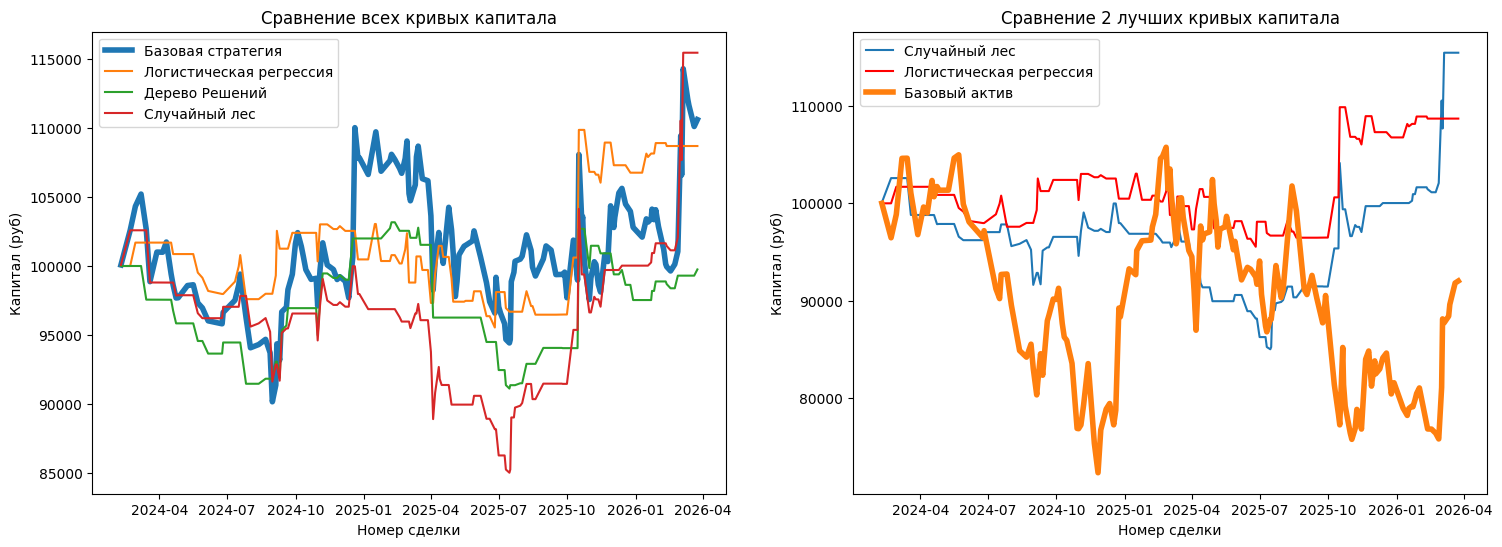

In [ ]:
def final_result(data, log_list, tree_list, random_forest_list, y_test_graph, share):
    """Функция для визуализации результатов стратегий

    Args:
        data (pd.DataFrame): Датафрейм со всеми признаками и целевой переменной
        log_list (np.array): Массив с результатами классификации для Логистической регрессии
        tree_list (np.array): Массив с результатами классификации для Дерева решений
        random_forest_list (np.array): Массив с результатами классификации для Случайного леса
    """
    y = y_test_graph[:, 1]
    new_df = pd.merge(share, pd.Series(y, name='time'))
    initial_price = new_df.loc[0, 'close']
    new_df['close'] = (new_df['close'] / initial_price) * 100_000
    
    y = np.array(data['profit_percent_net'])
    n = int(len(y) * 0.8)
    y_test = y[n:]
    
    df_result = pd.DataFrame({'profit_base' : y_test / 100, 'log' : log_list, 'dec_tree' : tree_list, 'random_forest' : random_forest_list})
    df_result['log_profit'] = df_result.apply(lambda row: row['profit_base'] if row['log']== 1 else 0, axis=1)
    df_result['dec_tree_profit'] = df_result.apply(lambda row: row['profit_base'] if row['dec_tree']== 1 else 0, axis=1)
    df_result['random_forest_profit'] = df_result.apply(lambda row: row['profit_base'] if row['random_forest']== 1 else 0, axis=1)
    dict_result = {}
    for name in ['log', 'dec_tree', 'random_forest']:
        list_result = []
        res = 100_000
        for i, profit in enumerate(df_result[f'{name}_profit']):
            if i == 0 and profit == 0:
                list_result.append(100_000)
            elif profit != 0:
                res = res*(1 + profit)
                list_result.append(res)
            elif profit == 0:
                list_result.append(res)
        dict_result[name] = list_result
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.lineplot(y=(100_000 * np.cumprod(1 + df_result['profit_base'])), x=y_test_graph[:, 1], ax=axes[0], linewidth=4, label='Базовая стратегия')
    sns.lineplot(y=dict_result['log'], x=y_test_graph[:, 1], ax=axes[0], label='Логистическая регрессия')
    sns.lineplot(y=dict_result['dec_tree'], x=y_test_graph[:, 1], ax=axes[0], label='Дерево Решений')
    sns.lineplot(y=dict_result['random_forest'], x=y_test_graph[:, 1], ax=axes[0], label='Случайный лес')
    axes[0].set_xlabel('Номер сделки')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    
    # Определение лучших стратегий
    max_dict = {'Базовая стратегия' : np.array(np.cumprod(1 + df_result['profit_base'])), 
                'Логистическая регрессия' : np.array(dict_result['log']), 
                'Дерево Решений' : np.array(dict_result['dec_tree']), 
                'Случайный лес' : np.array(dict_result['random_forest'])}
    max_arg1 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array1 = max_dict[max_arg1]
    del max_dict[max_arg1]
    max_arg2 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array2 = max_dict[max_arg2]
    

    sns.lineplot(y=max_array1, x=y_test_graph[:, 1], ax=axes[1], label=max_arg1)
    sns.lineplot(y=max_array2, x=y_test_graph[:, 1], ax=axes[1], label=max_arg2, color='red')
    sns.lineplot(y=new_df['close'], x=y_test_graph[:, 1], ax=axes[1], label='Базовый актив', linewidth=4)
    axes[1].set_xlabel('Номер сделки')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших кривых капитала')
    
    return (max_array1, max_arg1), (max_array2, max_arg2), np.array(np.cumprod(1 + df_result['profit_base']))
            
g = final_result(df_ml, result_log_reg_hypper, 
             result_dec_tree_hypper_without_features, 
             result_random_forest_with_features, y_test, tatneft_graph)



In [284]:
# Итоговые расчеты
# Доходность за период
total_return_base_strategy = np.round(((g[-1] / 100_000)[-1] - 1) * 100, 2)
total_return_strategy_1 = np.round(((g[0][0] / 100_000)[-1] - 1) * 100, 2)
total_return_strategy_2 = np.round(((g[1][0] / 100_000)[-1] - 1) * 100, 2)

# Профит фактор
def profit_factor(x):
    pnl = np.diff(x) / 100_000
    pnl_plus = np.sum(pnl[pnl > 0])
    pnl_minus = np.abs(np.sum(pnl[pnl < 0]))
    return np.round(pnl_plus / pnl_minus, 2)

pr_f_base_strategy = profit_factor(g[-1])
pr_f_strategy_1 = profit_factor(g[0][0])
pr_f_strategy_2 = profit_factor(g[1][0])

# Средняя прибыль и средний убыток за сделку
def mean_pr_loss(x):
    pnl = np.diff(x) / 100_000
    pnl_plus_mean = np.round(np.mean(pnl[pnl > 0]) * 100, 2)
    pnl_minus_mean = np.round(np.mean(np.abs(pnl[pnl < 0])) * 100, 2)
    return pnl_plus_mean, pnl_minus_mean
    
mean_profit_base_strategy, mean_loss_base_strategy = mean_pr_loss(g[-1])
mean_profit_strategy_1, mean_loss_strategy_1 = mean_pr_loss(g[0][0])
mean_profit_strategy_2, mean_loss_strategy_2 = mean_pr_loss(g[1][0])

# win_rate
def win_rate(x):
    pnl = np.diff(x) / 100_000
    pnl_plus_count = len((pnl[pnl >= 0]) * 100)
    pnl_minus_count = len((pnl[pnl < 0]) * 100)
    winrate = np.round(pnl_plus_count / (pnl_plus_count + pnl_minus_count), 3) * 100
    return winrate
    
win_rate_base_strategy = win_rate(g[-1])
win_rate_strategy_1 = win_rate(g[0][0])
win_rate_strategy_2 = win_rate(g[1][0])

In [287]:
pd.DataFrame(columns=['total return', 'profit factor', 'mean_profit', 'mean_loss', 'win rate'],
             data=[[total_return_base_strategy, pr_f_base_strategy, mean_profit_base_strategy, mean_loss_base_strategy, win_rate_base_strategy],
                   [total_return_strategy_1, pr_f_strategy_1, mean_profit_strategy_1, mean_loss_strategy_1, win_rate_strategy_1], 
                   [total_return_strategy_2, pr_f_strategy_2, mean_profit_strategy_2, mean_loss_strategy_2, win_rate_strategy_2]],
             index=['base_strategy', f'{g[0][1]}', f'{g[1][1]}'])

,total return,profit factor,mean_profit,mean_loss,win rate
base_strategy,-7.98,0.96,2.22,2.37,51.2
Случайный лес,15.47,1.29,1.83,1.38,76.5
Логистическая регрессия,8.70,1.22,1.72,1.24,80.2
